## Vinicius Torralles, RM: 570911
## Mariana Carminato, RM: 573248
#
## Gabriel Jurado, RM: 571236
## Guilherme Garbelini, RM: 571150

In [1]:
import json
import urllib.parse
import urllib.request
import csv

In [4]:
def consultar_api(endereco, parametros):
    url = endereco + "?" + urllib.parse.urlencode(parametros)
    try:
        with urllib.request.urlopen(url, timeout=30) as resposta:
            return json.load(resposta)
    except Exception as erro:
        raise RuntimeError(f"Não foi possível consultar a API: {erro}") from erro

In [5]:
URL_ANEEL = "https://dadosabertos.aneel.gov.br/api/3/action/datastore_search"

ID_RECURSO = "11ec447d-698d-4ab8-977f-b424d5deee6a"

SIGLAS = ["UFV", "EOL", "UHE", "PCH", "CGH"]

print("API ANEEL configurada!")

API ANEEL configurada!


In [6]:
registros_aneel = []

for sigla in SIGLAS:

    parametros = {
        "resource_id": ID_RECURSO,
        "filters": json.dumps({
            "SigTipoGeracao": sigla
        }),
        "limit": 1200
    }

    resposta = consultar_api(
        URL_ANEEL,
        parametros
    )

    if not resposta.get("success"):
        raise ValueError(
            f"Consulta da ANEEL falhou para {sigla}"
        )

    linhas = resposta["result"]["records"]

    print(f"{sigla}: {len(linhas)} linhas recebidas")

    registros_aneel.extend(linhas)

print()
print("Total de linhas recebidas:", len(registros_aneel))

UFV: 1200 linhas recebidas
EOL: 1200 linhas recebidas
UHE: 221 linhas recebidas
PCH: 537 linhas recebidas
CGH: 718 linhas recebidas

Total de linhas recebidas: 3876


In [7]:
def numero(valor):

    texto = str(valor).strip()

    if "," in texto:
        texto = texto.replace(".", "").replace(",", ".")

    try:
        return float(texto)

    except ValueError:
        return None


fontes = {
    "UFV": "Solar",
    "EOL": "Eólica",
    "UHE": "Hidráulica",
    "PCH": "Hidráulica",
    "CGH": "Hidráulica"
}


linhas_classificacao = []

for registro in registros_aneel:

    potencia = numero(
        registro.get("MdaPotenciaOutorgadaKw")
    )

    latitude = numero(
        registro.get("NumCoordNEmpreendimento")
    )

    longitude = numero(
        registro.get("NumCoordEEmpreendimento")
    )

    fonte = fontes.get(
        registro.get("SigTipoGeracao")
    )

    if fonte and all(
        valor is not None
        for valor in (
            potencia,
            latitude,
            longitude
        )
    ):

        linhas_classificacao.append([
            potencia,
            latitude,
            longitude,
            fonte
        ])


if len(linhas_classificacao) < 90:
    raise ValueError(
        "Poucos registros válidos. Confira a resposta da ANEEL."
    )


print(
    "Linhas válidas:",
    len(linhas_classificacao)
)

print(
    "Primeiro exemplo:",
    linhas_classificacao[0]
)

Linhas válidas: 3876
Primeiro exemplo: [20.48, -10.44277778, -64.15194444, 'Solar']


In [8]:
with open(
    "aneel_classificacao_orange.csv",
    "w",
    newline="",
    encoding="utf-8-sig"
) as arquivo:

    escritor = csv.writer(arquivo)

    escritor.writerow([
        "potencia_kw",
        "latitude",
        "longitude",
        "fonte"
    ])

    escritor.writerows(
        linhas_classificacao
    )


print(
    "Salvo: aneel_classificacao_orange.csv"
)

Salvo: aneel_classificacao_orange.csv


In [9]:
URL_METEO = "https://archive-api.open-meteo.com/v1/archive"

parametros_meteo = {

    "latitude": -9.39,

    "longitude": -40.50,

    "start_date": "2025-04-01",

    "end_date": "2025-06-30",

    "timezone": "America/Recife",

    "hourly": ",".join([
        "temperature_2m",
        "relative_humidity_2m",
        "cloud_cover",
        "wind_speed_10m",
        "shortwave_radiation"
    ])
}

print("Open-Meteo configurado!")

Open-Meteo configurado!


In [10]:
resposta_meteo = consultar_api(
    URL_METEO,
    parametros_meteo
)

if "hourly" not in resposta_meteo:
    raise ValueError(
        "Resposta sem a seção hourly"
    )

horas_api = resposta_meteo["hourly"]

print(
    "Campos recebidos:",
    list(horas_api)
)

print()

print(
    "Unidades informadas pela API:",
    resposta_meteo.get(
        "hourly_units",
        {}
    )
)

print()

print(
    "Quantidade de horários:",
    len(horas_api["time"])
)

Campos recebidos: ['time', 'temperature_2m', 'relative_humidity_2m', 'cloud_cover', 'wind_speed_10m', 'shortwave_radiation']

Unidades informadas pela API: {'time': 'iso8601', 'temperature_2m': '°C', 'relative_humidity_2m': '%', 'cloud_cover': '%', 'wind_speed_10m': 'km/h', 'shortwave_radiation': 'W/m²'}

Quantidade de horários: 2184


In [11]:
nomes_api = [
    "temperature_2m",
    "relative_humidity_2m",
    "cloud_cover",
    "wind_speed_10m",
    "shortwave_radiation"
]


linhas_regressao = []


for indice, data_hora in enumerate(
    horas_api["time"]
):

    hora = int(
        data_hora[11:13]
    )

    valores = [
        horas_api[nome][indice]
        for nome in nomes_api
    ]

    if (
        7 <= hora <= 17
        and all(
            valor is not None
            for valor in valores
        )
    ):

        linhas_regressao.append([
            data_hora,
            *valores[:4],
            hora,
            valores[4]
        ])


if len(linhas_regressao) < 100:
    raise ValueError(
        "Poucos horários válidos. Confira a resposta do Open-Meteo."
    )


print(
    "Horas válidas:",
    len(linhas_regressao)
)

print(
    "Primeiro exemplo:",
    linhas_regressao[0]
)

Horas válidas: 1001
Primeiro exemplo: ['2025-04-01T07:00', 25.3, 74, 100, 17.7, 7, 116.0]


In [12]:
with open(
    "meteo_regressao_orange.csv",
    "w",
    newline="",
    encoding="utf-8-sig"
) as arquivo:

    escritor = csv.writer(arquivo)

    escritor.writerow([
        "data_hora",
        "temperatura_c",
        "umidade_pct",
        "nuvens_pct",
        "vento_kmh",
        "hora",
        "radiacao_w_m2"
    ])

    escritor.writerows(
        linhas_regressao
    )


print(
    "Salvo: meteo_regressao_orange.csv"
)

Salvo: meteo_regressao_orange.csv


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Bibliotecas de classificação carregadas!")

Bibliotecas de classificação carregadas!


In [15]:
df_aneel = pd.read_csv(
    "aneel_classificacao_orange.csv"
)

print("Quantidade de linhas:", len(df_aneel))
print()
print("Colunas:")
print(df_aneel.columns.tolist())
print()
print("Primeiras linhas:")
display(df_aneel.head())

Quantidade de linhas: 3876

Colunas:
['potencia_kw', 'latitude', 'longitude', 'fonte']

Primeiras linhas:


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar


In [16]:
print("Informações do dataset:")
print()

df_aneel.info()

print()
print("Valores ausentes:")
print(df_aneel.isnull().sum())

Informações do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3876 entries, 0 to 3875
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   potencia_kw  3876 non-null   float64
 1   latitude     3876 non-null   float64
 2   longitude    3876 non-null   float64
 3   fonte        3876 non-null   object 
dtypes: float64(3), object(1)
memory usage: 121.3+ KB

Valores ausentes:
potencia_kw    0
latitude       0
longitude      0
fonte          0
dtype: int64


In [17]:
print("Quantidade de empreendimentos por fonte:")
print()

print(
    df_aneel["fonte"].value_counts()
)

Quantidade de empreendimentos por fonte:

fonte
Hidráulica    1476
Solar         1200
Eólica        1200
Name: count, dtype: int64


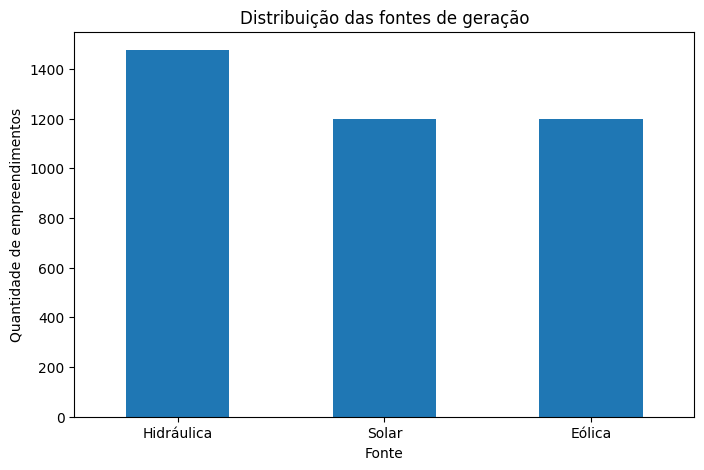

In [18]:
plt.figure(figsize=(8, 5))

df_aneel["fonte"].value_counts().plot(
    kind="bar"
)

plt.title("Distribuição das fontes de geração")
plt.xlabel("Fonte")
plt.ylabel("Quantidade de empreendimentos")
plt.xticks(rotation=0)

plt.show()

In [19]:
X = df_aneel[
    [
        "potencia_kw",
        "latitude",
        "longitude"
    ]
]

y = df_aneel["fonte"]

print("Entradas X:")
display(X.head())

print()
print("Alvo y:")
display(y.head())

Entradas X:


,potencia_kw,latitude,longitude
0,20.48,-10.442778,-64.151944
1,5000.00,-6.003889,-40.274722
2,12.26,-23.557778,-46.734000
3,3.00,-23.558889,-46.735000
4,1.70,-23.493819,-46.845000



Alvo y:


,fonte
0,Solar
1,Solar
2,Solar
3,Solar
4,Solar


In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Treino:", len(X_train))
print("Teste:", len(X_test))

Treino: 3100
Teste: 776


In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Padronização concluída!")

Padronização concluída!


In [23]:
modelo_logistico = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_knn = KNeighborsClassifier(
    n_neighbors=5
)

modelo_random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_logistico.fit(
    X_train_scaled,
    y_train
)

modelo_knn.fit(
    X_train_scaled,
    y_train
)

modelo_random_forest.fit(
    X_train,
    y_train
)

print("Os 3 modelos foram treinados!")

Os 3 modelos foram treinados!


In [24]:
previsoes_logistico = modelo_logistico.predict(
    X_test_scaled
)

previsoes_knn = modelo_knn.predict(
    X_test_scaled
)

previsoes_random_forest = modelo_random_forest.predict(
    X_test
)

print("Previsões realizadas!")

Previsões realizadas!


In [25]:
resultados_classificacao = []

modelos_classificacao = {
    "Regressão Logística": previsoes_logistico,
    "KNN": previsoes_knn,
    "Random Forest": previsoes_random_forest
}

for nome, previsoes in modelos_classificacao.items():

    accuracy = accuracy_score(
        y_test,
        previsoes
    )

    precision = precision_score(
        y_test,
        previsoes,
        average="macro",
        zero_division=0
    )

    recall = recall_score(
        y_test,
        previsoes,
        average="macro",
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        previsoes,
        average="macro",
        zero_division=0
    )

    resultados_classificacao.append([
        nome,
        accuracy,
        precision,
        recall,
        f1
    ])


tabela_classificacao = pd.DataFrame(
    resultados_classificacao,
    columns=[
        "Modelo",
        "Accuracy",
        "Precision (Macro)",
        "Recall (Macro)",
        "F1 (Macro)"
    ]
)

display(
    tabela_classificacao.round(4)
)

,Modelo,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro)
0,Regressão Logística,0.8247,0.8282,0.8214,0.8197
1,KNN,0.9652,0.9663,0.9636,0.9648
2,Random Forest,0.9755,0.9769,0.9741,0.9753


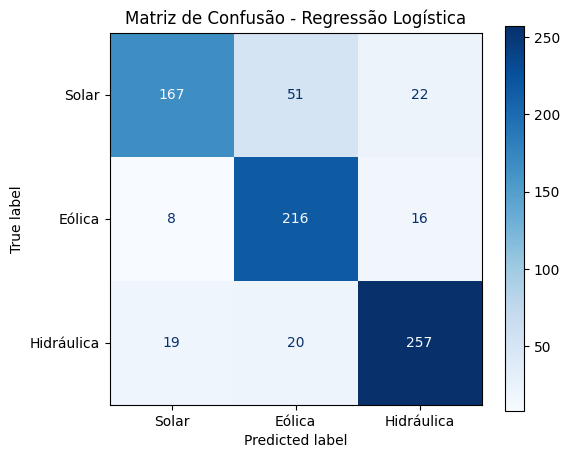

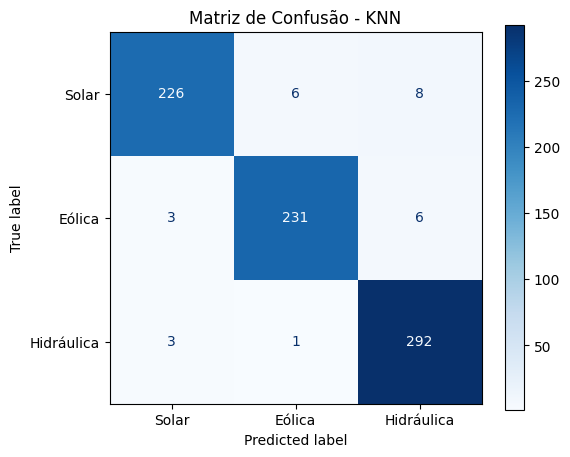

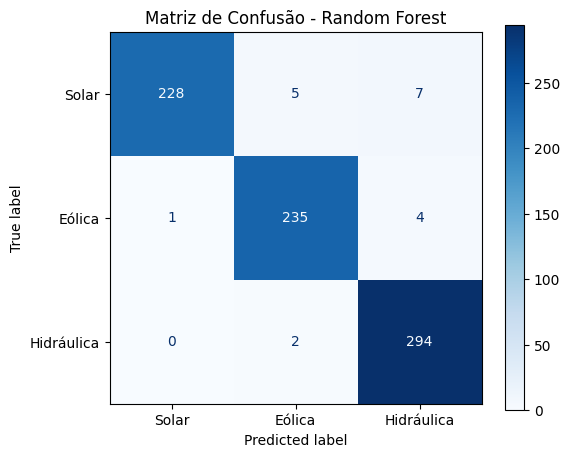

In [26]:
modelos_para_matriz = {
    "Regressão Logística": (
        y_test,
        previsoes_logistico
    ),

    "KNN": (
        y_test,
        previsoes_knn
    ),

    "Random Forest": (
        y_test,
        previsoes_random_forest
    )
}

for nome, (real, previsto) in modelos_para_matriz.items():

    matriz = confusion_matrix(
        real,
        previsto,
        labels=["Solar", "Eólica", "Hidráulica"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=[
            "Solar",
            "Eólica",
            "Hidráulica"
        ]
    )

    fig, ax = plt.subplots(
        figsize=(6, 5)
    )

    disp.plot(
        ax=ax,
        cmap="Blues"
    )

    plt.title(
        f"Matriz de Confusão - {nome}"
    )

    plt.show()

## Interpretação dos resultados — Classificação ANEEL

Foram utilizados três atributos de entrada: potência outorgada em kW, latitude e longitude. A variável alvo foi fonte, com as classes Solar, Eólica e Hidráulica. A divisão dos dados foi feita em 80% para treinamento e 20% para teste, de forma estratificada e com semente fixa.

Os três modelos apresentaram resultados diferentes. A Regressão Logística obteve Accuracy de 0,8247 e F1 macro de 0,8197. O KNN apresentou desempenho superior, com Accuracy de 0,9652 e F1 macro de 0,9648. O Random Forest apresentou Accuracy de 0,9755 e F1 macro de 0,9753.

Nas matrizes de confusão, a Regressão Logística apresentou maior quantidade de erros, principalmente na distinção entre as classes Solar e Eólica. O KNN reduziu consideravelmente essas confusões. O Random Forest apresentou a menor quantidade de erros entre os três modelos, com 228 exemplos Solar classificados corretamente, 235 exemplos Eólica classificados corretamente e 294 exemplos Hidráulica classificados corretamente.

Os resultados mostram que potência e localização conseguem fornecer informações relevantes para a classificação, mas não são suficientes para representar todas as características que diferenciam as fontes de geração. Em uma aplicação real, seria possível considerar outras variáveis relacionadas ao empreendimento, desde que elas não revelem diretamente a classe a ser prevista.

A escolha do modelo para esta tarefa seria o Random Forest, pois, neste conjunto de teste, apresentou os maiores valores de Accuracy, Precision macro, Recall macro e F1 macro.

In [27]:
df_meteo = pd.read_csv(
    "meteo_regressao_orange.csv"
)

print("Quantidade de linhas:", len(df_meteo))
print()

print("Colunas:")
print(df_meteo.columns.tolist())

print()

print("Primeiras linhas:")
display(df_meteo.head())

Quantidade de linhas: 1001

Colunas:
['data_hora', 'temperatura_c', 'umidade_pct', 'nuvens_pct', 'vento_kmh', 'hora', 'radiacao_w_m2']

Primeiras linhas:


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01T07:00,25.3,74,100,17.7,7,116.0
1,2025-04-01T08:00,26.5,66,100,18.1,8,269.0
2,2025-04-01T09:00,28.4,55,97,18.0,9,529.0
3,2025-04-01T10:00,30.8,44,21,18.4,10,797.0
4,2025-04-01T11:00,32.7,36,26,20.1,11,880.0


In [28]:
print("Informações do dataset:")
print()

df_meteo.info()

print()

print("Valores ausentes:")
print(
    df_meteo.isnull().sum()
)

Informações do dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   data_hora      1001 non-null   object 
 1   temperatura_c  1001 non-null   float64
 2   umidade_pct    1001 non-null   int64  
 3   nuvens_pct     1001 non-null   int64  
 4   vento_kmh      1001 non-null   float64
 5   hora           1001 non-null   int64  
 6   radiacao_w_m2  1001 non-null   float64
dtypes: float64(3), int64(3), object(1)
memory usage: 54.9+ KB

Valores ausentes:
data_hora        0
temperatura_c    0
umidade_pct      0
nuvens_pct       0
vento_kmh        0
hora             0
radiacao_w_m2    0
dtype: int64


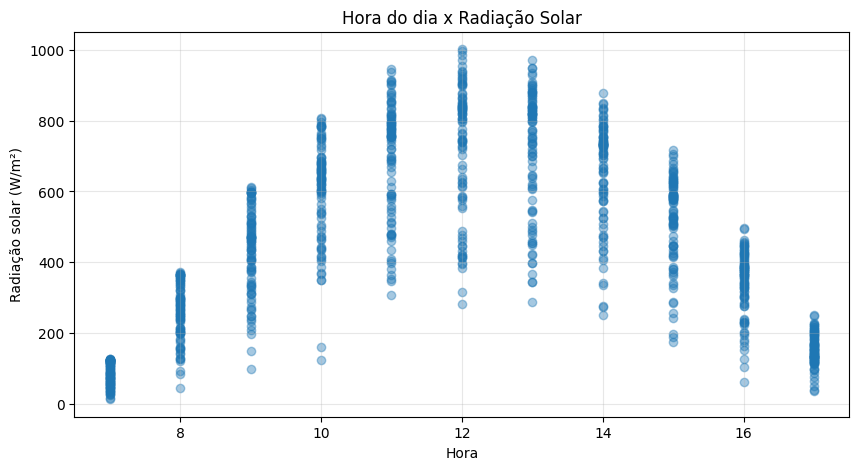

In [29]:
plt.figure(figsize=(10, 5))

plt.scatter(
    df_meteo["hora"],
    df_meteo["radiacao_w_m2"],
    alpha=0.4
)

plt.title(
    "Hora do dia x Radiação Solar"
)

plt.xlabel("Hora")
plt.ylabel("Radiação solar (W/m²)")

plt.grid(alpha=0.3)

plt.show()

In [30]:
X_reg = df_meteo[
    [
        "temperatura_c",
        "umidade_pct",
        "nuvens_pct",
        "vento_kmh",
        "hora"
    ]
]

y_reg = df_meteo[
    "radiacao_w_m2"
]

print("Entradas X:")
display(X_reg.head())

print()

print("Alvo y:")
display(y_reg.head())

Entradas X:


,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora
0,25.3,74,100,17.7,7
1,26.5,66,100,18.1,8
2,28.4,55,97,18.0,9
3,30.8,44,21,18.4,10
4,32.7,36,26,20.1,11



Alvo y:


,radiacao_w_m2
0,116.0
1,269.0
2,529.0
3,797.0
4,880.0


In [31]:
indice_corte = int(
    len(df_meteo) * 0.80
)

X_train_reg = X_reg.iloc[
    :indice_corte
]

X_test_reg = X_reg.iloc[
    indice_corte:
]

y_train_reg = y_reg.iloc[
    :indice_corte
]

y_test_reg = y_reg.iloc[
    indice_corte:
]

print(
    "Dados de treinamento:",
    len(X_train_reg)
)

print(
    "Dados de teste:",
    len(X_test_reg)
)

print()

print(
    "Primeira data do treino:",
    df_meteo["data_hora"].iloc[0]
)

print(
    "Última data do treino:",
    df_meteo["data_hora"].iloc[indice_corte - 1]
)

print(
    "Primeira data do teste:",
    df_meteo["data_hora"].iloc[indice_corte]
)

print(
    "Última data do teste:",
    df_meteo["data_hora"].iloc[-1]
)

Dados de treinamento: 800
Dados de teste: 201

Primeira data do treino: 2025-04-01T07:00
Última data do treino: 2025-06-12T14:00
Primeira data do teste: 2025-06-12T15:00
Última data do teste: 2025-06-30T17:00


In [32]:
scaler_reg = StandardScaler()

X_train_reg_scaled = scaler_reg.fit_transform(
    X_train_reg
)

X_test_reg_scaled = scaler_reg.transform(
    X_test_reg
)

print("Padronização concluída!")

Padronização concluída!


In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

modelo_linear = LinearRegression()

modelo_random_forest_reg = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

modelo_gradient_boosting = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

print("3 modelos de regressão criados!")

3 modelos de regressão criados!


In [34]:
modelo_linear.fit(
    X_train_reg_scaled,
    y_train_reg
)

modelo_random_forest_reg.fit(
    X_train_reg,
    y_train_reg
)

modelo_gradient_boosting.fit(
    X_train_reg,
    y_train_reg
)

print("Os 3 modelos foram treinados!")

Os 3 modelos foram treinados!


In [35]:
previsoes_linear = modelo_linear.predict(
    X_test_reg_scaled
)

previsoes_random_forest_reg = (
    modelo_random_forest_reg.predict(
        X_test_reg
    )
)

previsoes_gradient_boosting = (
    modelo_gradient_boosting.predict(
        X_test_reg
    )
)

print("Previsões realizadas!")

Previsões realizadas!


In [36]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

modelos_regressao = {
    "Regressão Linear": previsoes_linear,
    "Random Forest": previsoes_random_forest_reg,
    "Gradient Boosting": previsoes_gradient_boosting
}

resultados_regressao = []

for nome, previsoes in modelos_regressao.items():

    mae = mean_absolute_error(
        y_test_reg,
        previsoes
    )

    mse = mean_squared_error(
        y_test_reg,
        previsoes
    )

    r2 = r2_score(
        y_test_reg,
        previsoes
    )

    resultados_regressao.append([
        nome,
        mae,
        mse,
        r2
    ])


tabela_regressao = pd.DataFrame(
    resultados_regressao,
    columns=[
        "Modelo",
        "MAE (W/m²)",
        "MSE ((W/m²)²)",
        "R²"
    ]
)

display(
    tabela_regressao.round(4)
)

,Modelo,MAE (W/m²),MSE ((W/m²)²),R²
0,Regressão Linear,145.2049,30034.2011,0.3598
1,Random Forest,66.2517,7250.8882,0.8455
2,Gradient Boosting,64.2233,7261.4283,0.8452


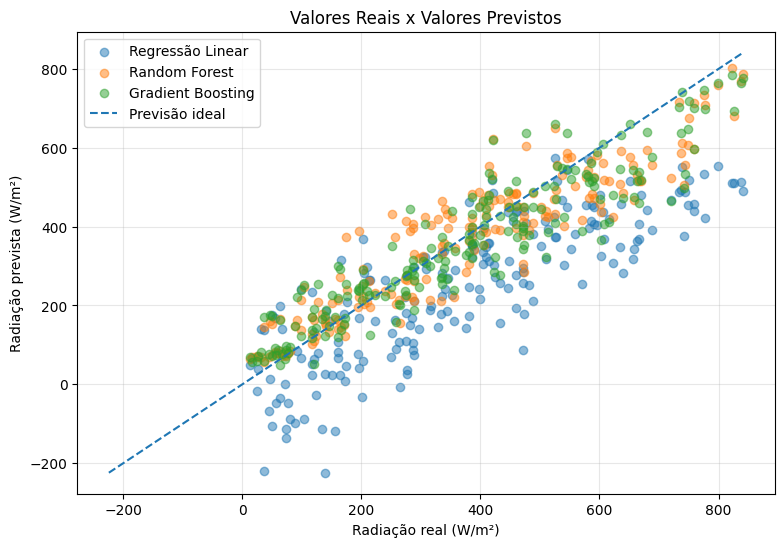

In [37]:
plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_reg,
    previsoes_linear,
    alpha=0.5,
    label="Regressão Linear"
)

plt.scatter(
    y_test_reg,
    previsoes_random_forest_reg,
    alpha=0.5,
    label="Random Forest"
)

plt.scatter(
    y_test_reg,
    previsoes_gradient_boosting,
    alpha=0.5,
    label="Gradient Boosting"
)

limite_min = min(
    y_test_reg.min(),
    previsoes_linear.min(),
    previsoes_random_forest_reg.min(),
    previsoes_gradient_boosting.min()
)

limite_max = max(
    y_test_reg.max(),
    previsoes_linear.max(),
    previsoes_random_forest_reg.max(),
    previsoes_gradient_boosting.max()
)

plt.plot(
    [limite_min, limite_max],
    [limite_min, limite_max],
    linestyle="--",
    label="Previsão ideal"
)

plt.title(
    "Valores Reais x Valores Previstos"
)

plt.xlabel(
    "Radiação real (W/m²)"
)

plt.ylabel(
    "Radiação prevista (W/m²)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Interpretação dos resultados — Regressão

Foram utilizados como variáveis de entrada a temperatura, a umidade relativa, a cobertura de nuvens, a velocidade do vento e a hora do dia. A variável prevista foi a radiação solar em W/m².

A divisão dos dados foi realizada respeitando a ordem temporal, utilizando aproximadamente 80% das primeiras observações para treinamento e 20% das últimas observações para teste, sem embaralhamento.

Foram comparados três modelos: Regressão Linear, Random Forest e Gradient Boosting.

A Regressão Linear apresentou MAE de 145,2049 W/m², MSE de 30034,2011 e R² de 0,3598. O Random Forest apresentou MAE de 66,2517 W/m², MSE de 7250,8882 e R² de 0,8455. O Gradient Boosting apresentou MAE de 64,2233 W/m², MSE de 7261,4283 e R² de 0,8452.

Os resultados mostram uma diferença significativa entre a Regressão Linear e os dois modelos baseados em árvores. O Random Forest e o Gradient Boosting apresentaram valores de MAE muito menores e valores de R² próximos de 0,85, indicando que conseguiram representar melhor os dados de teste. A Regressão Linear apresentou desempenho inferior neste conjunto de dados.

O gráfico de valores reais versus previstos também mostra que as previsões do Random Forest e do Gradient Boosting ficaram, em geral, mais próximas da linha de previsão ideal do que as previsões da Regressão Linear.

### Importância da hora do dia

A hora do dia é uma variável importante para estimar a radiação solar porque a disponibilidade de radiação varia ao longo do dia. Durante o período diurno, a posição do Sol e a quantidade de energia solar incidente mudam conforme o horário. Por isso, incluir a hora como variável de entrada fornece aos modelos uma informação temporal relevante para estimar a radiação.

### Radiação solar x geração elétrica

Radiação solar e geração elétrica não são a mesma coisa. A radiação solar representa a quantidade de energia solar que chega a uma determinada superfície, enquanto a geração elétrica depende da conversão dessa energia pelos equipamentos de geração, como os painéis fotovoltaicos.

Na prática, a geração também pode ser influenciada por fatores como potência instalada, eficiência dos equipamentos, temperatura dos módulos, orientação e inclinação dos painéis, sombreamento, perdas elétricas e condições de operação.

Portanto, mesmo que a radiação solar seja alta, isso não significa necessariamente que a geração elétrica terá exatamente o mesmo comportamento ou valor proporcional.